In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scipy.io import loadmat
import matplotlib.pyplot as plt
# Enable cuDNN
tf.keras.backend.set_image_data_format('channels_first')

In [2]:
# Load data
z3 = loadmat('z3.mat')['z3']
z3 = np.array(z3)

# Split data into inputs and outputs
X = z3[:, :6]
Y = z3[:, 6:]

# Normalize joint angles to be between -1 and 1
Y = Y / np.pi
print(Y)

# Shuffle data
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]

[[-0.5        -1.         -0.5        -0.5         0.76923077 -0.25      ]
 [-0.5        -1.         -0.5        -0.5         0.76923077 -0.21153846]
 [-0.5        -1.         -0.5        -0.5         0.76923077 -0.17307692]
 ...
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.17307692]
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.21153846]
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.25      ]]


In [10]:
def train_validate_test_split(x, y, train_size=0.7, validate_size=0.15, test_size=0.15, random_state=None):
    if validate_size + test_size >= 1.0:
        raise ValueError("The sum of validate_size and test_size should be less than 1.0.")
    
    x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size=train_size, random_state=random_state)
    
    remaining = 1.0 - train_size
    validate_ratio = validate_size / (validate_size + test_size)
    test_ratio = test_size / (validate_size + test_size)
    
    x_validate, x_test, y_validate, y_test = train_test_split(x_temp, y_temp, train_size=validate_ratio, test_size=test_ratio, random_state=random_state)
    
    return x_train, x_validate, x_test, y_train, y_validate, y_test

# Train-validate-test split
X_train, X_validate ,X_test, Y_train, Y_validate ,Y_test = train_validate_test_split(X, Y , train_size=0.7, validate_size=0.15, test_size=0.15, random_state=42)
# Create a fully connected neural network model
model = keras.Sequential([
        keras.layers.Dense(6),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
         keras.layers.Dense(256, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(6)  # Output layer with 6 neurons (x, y, z, a, b, c)
])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("model_z3.h5", save_best_only=True, monitor='val_loss', mode='min')

# Learning rate scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mean_squared_error'])

# Train the model
history = model.fit(X_train, Y_train, epochs=1000, validation_data=(X_validate, Y_validate),
                    batch_size=400, shuffle=True, callbacks=[early_stopping, model_checkpoint])

Epoch 1/1000
5397/5397 [==============================] - 145s 27ms/step - loss: 0.2592 - mean_squared_error: 0.2592 - val_loss: 0.0037 - val_mean_squared_error: 0.0037
Epoch 2/1000
5397/5397 [==============================] - 142s 26ms/step - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0034 - val_mean_squared_error: 0.0034
Epoch 3/1000
5397/5397 [==============================] - 143s 26ms/step - loss: 0.0019 - mean_squared_error: 0.0019 - val_loss: 0.0016 - val_mean_squared_error: 0.0016
Epoch 4/1000
5397/5397 [==============================] - 143s 26ms/step - loss: 0.0013 - mean_squared_error: 0.0013 - val_loss: 0.0012 - val_mean_squared_error: 0.0012
Epoch 5/1000
5397/5397 [==============================] - 143s 26ms/step - loss: 9.2774e-04 - mean_squared_error: 9.2774e-04 - val_loss: 8.1529e-04 - val_mean_squared_error: 8.1529e-04
Epoch 6/1000
5397/5397 [==============================] - 143s 26ms/step - loss: 7.0715e-04 - mean_squared_error: 7.0715e-04 - val_loss: 6.

In [11]:
# Evaluate the model on the test set
test_loss, _ = model.evaluate(X_test, Y_test)
print(f'Test Loss: {test_loss}')

9251/9251 [==============================] - 108s 12ms/step - loss: 4.4919e-04 - mean_squared_error: 4.4919e-04
Test Loss: 0.0004491914587561041


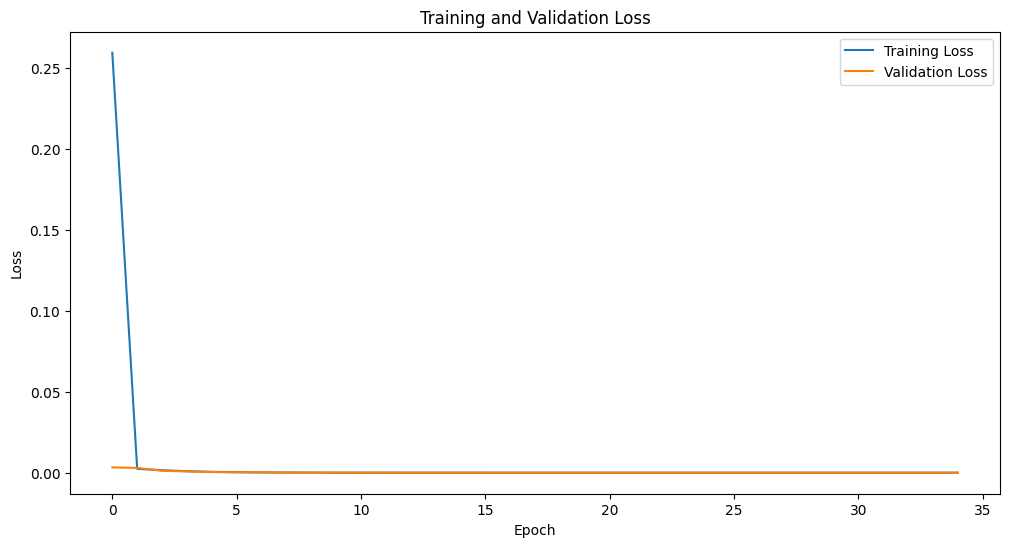

In [12]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

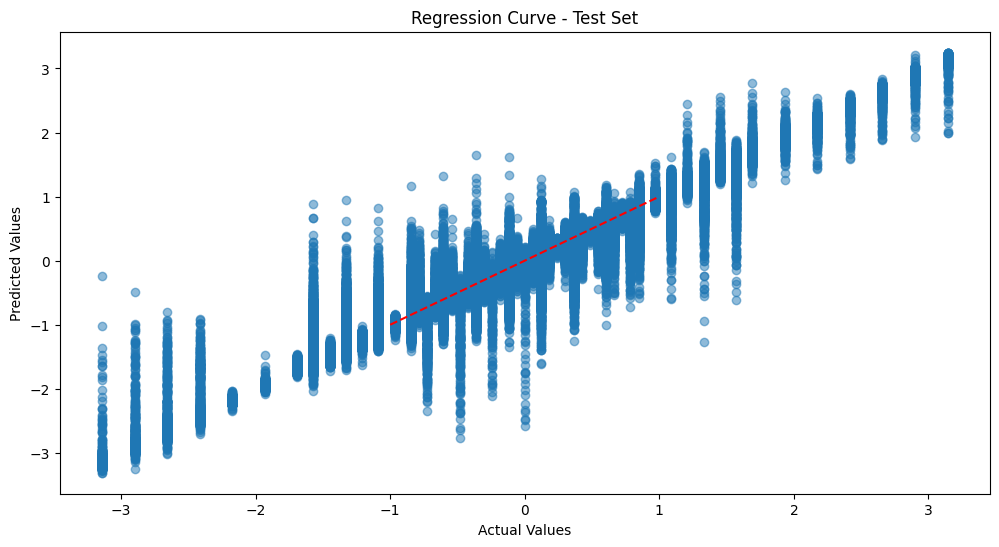

In [13]:
# Plot regression curve for test set
test_predictions = model.predict(X_test) * np.pi  # Use 'model' instead of 'best_model'
plt.figure(figsize=(12, 6))
plt.scatter(Y_test * np.pi, test_predictions, alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--')
plt.title('Regression Curve - Test Set')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

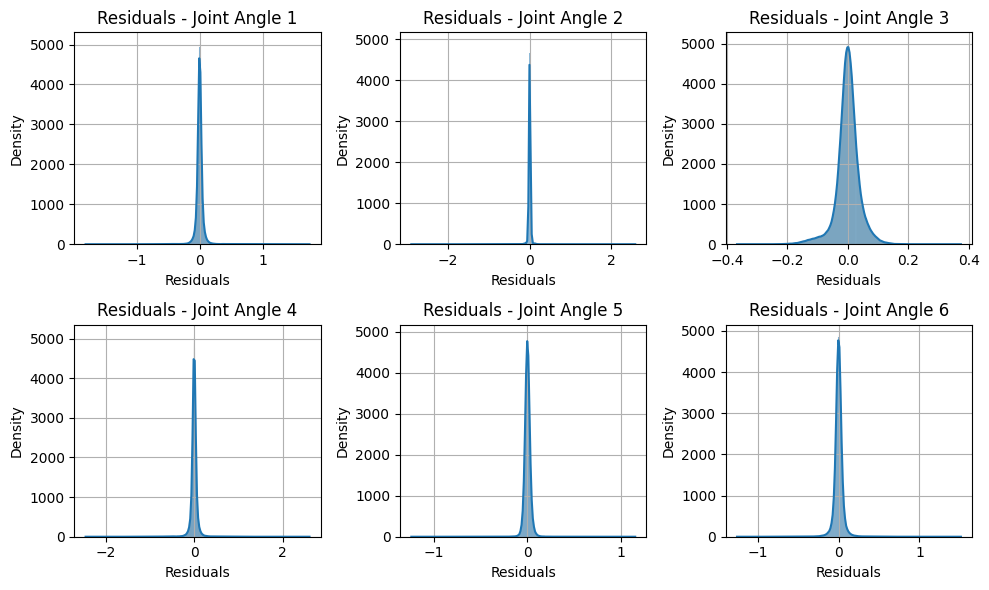

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
# Residual plots
residuals = Y_test - predictions

plt.figure(figsize=(10, 6))
for i in range(6):  # Assuming you have 6 joint angles
    plt.subplot(2, 3, i + 1)
    sns.histplot(residuals[:, i], kde=True)
    plt.title(f'Residuals - Joint Angle {i + 1}')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Load the best model for predictions
best_model = tf.keras.models.load_model("model_z3.h5")

# Test the loaded model with [10, 20, 30, 40, 50, 60]
test_inputs = np.array([[350,352.139380484327,188.302222155949,1.57079632679490,0,0]])
predictions = best_model.predict(test_inputs) * np.pi

print("Predictions for test inputs:")
print(predictions)

Predictions for test inputs:
[[-1.5523187  -2.8299155  -0.38836136 -1.7276143   1.5257244  -0.42567024]]
